# COSC-635: Lab 3

**Ben Miller**

[PLACEHOLDER_FOR_NOTEBOOK_LINK]

## Getting Started

Follow the instructions below to copy this notebook and to perform some initial setup.

1. Copy this notebook by selecting `File > Save a copy in Drive`.
2. A new window should open for the copied notebook. Move the new notebook to your course folder in Google Drive by selecting `File > Move` and then selecting the desired folder.
3. Update the name of the notebook by removing "Copy of" and replacing "Username" with your actual username.
4. Update the first cell in the notebook by specifying your course number (435 or 635) and by replacing "Student Name" with your actual name.
5. Do not edit the line that says `PLACEHOLDER_FOR_NOTEBOOK_LINK`. This will be used by the [notebook renderer](https://colab.research.google.com/drive/1CJTipys46ldZxJFwnt7XbdjQUfkmoXeU?usp=sharing) tool to insert a link to your Colab notebook.
6. Enable link sharing for your notebook.

## Preparing the Colab Environment

Run the cell below to install gymnasium and to download rltools to the virtual machine.

In [1]:
%%capture
!rm rltools -r
!git clone https://github.com/drbeane/rltools.git

The cell below includes the import statements that you will need for this assignmnet. No other import statements should be added anywhere in the notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

import rltools
import rltools.gym as gym
from rltools.utils import evaluate, create_gif
from rltools.dynamic_prog import DPAgent
from rltools.monte_carlo import MCAgent
from rltools.temp_diff import TDAgent
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

## Note on Variable Names

You are free to select the variable names for the objects that you create in this notebook. But please make sure that the variable names you select in each part are distinct from those in other parts. An exception to this rule can be made in instances where a particular variable will be used in a single cell, but no where else in the notebook.

## Note on Scoring Models

In this lab and in future labs, we will score models by subtracting the standard deviation of their returnfrom the mean of their returns. The formula for this metric is provided below.

$$\textrm{score} =  \textrm{Mean}[\textrm{Return}] - \textrm{StdDev}[\textrm{Return}]$$

<br>
This score favors policies that have high returns, with lower variability in the return between episodes.

## Note on Progress Bars

The `control` and `q_learning` methods used in this assignment each have a `show_progress` parameter which has a default value of `False`. Setting this parameter to `True` will display a progress bar that tracks the training progress. This can be useful, but including progress bars will cause the Notebook rendering to fail due to a bug in one of the packages used for the rendering. Please **do not** set this paramater to `True`. Or, if you do, please set it back to `False` before performing your final Restart and Run All operation.

# Part 1 - Frozen Lake

In Part 1 of this assignment, you will apply a variety of control methods to the Frozen Lake environment. In particular, you will apply value iteration, Monte Carlo control, and Q-learning.

## 1.A - Create Environment

In the cell below, we create an 16x16 instance of the Frozen Lake environment. You can rename this environment if you wish. Otherwise, run this cell as-is.

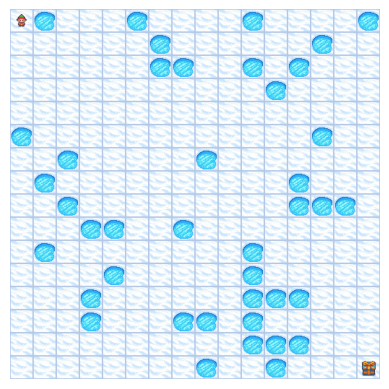

In [3]:
env1 = gym.make(
    'FrozenLake-v1',
    prob = 0.9,
    rew_struct = [-0.2, -10, 100],
    desc = generate_random_map(size=16, p=0.8, seed=8),
    render_mode = 'rgb_array'
)

state, info = env1.reset()
plt.imshow(env1.render())
plt.axis('off')
plt.show()

## 1.B - Value Iteration

Complete the following steps in the cell below:

1. Create an instance of `DPAgent` for the environment from 1A. Set a discount rate of 1.0 and a seed of 1.
2. Use the agent to perform value iteration.
3. Use `evaluate()` to evaluate the optimal policy. Set `episodes=5_000`, `gamma=1.0`, `seed=1`, and `check_success=True`.

In [4]:
dp_agent = DPAgent(env1, gamma=1.0, seed=1)
dp_agent.value_iteration()
dp_results = evaluate(env1, dp_agent, gamma=1.0, episodes=5000, seed=1, check_success=True)

Value iteration required 328 steps to converge.
Mean Return:    83.7695
StdDev Return:  24.6605
Mean Length:    52.3424
StdDev Length:  20.0382
Success Rate:   0.9458


In the cell below, replace the blanks with the name of the dictionary returned by `evaluate()` in the previous step and then run the cell. You should see that the score for the optimal model model is equal to approximately $83.77 - 24.66 = 59.11$.

In [5]:
print(dp_results['mean_return'] - dp_results['stdev_return'])

59.108975663558326


## 1.C - Monte Carlo Control

Create an instance of `MCAgent` for `env1` with `gamma=1.0`. Then apply Monte Carlo control using the parameter described below.

* Train for 30,000 episodes.
* Set `max_steps=500`.
* Set `seed=1`.
* Use exploring starts.
* Set `check_success=True`.
* Set `updates=1000`.
* Set `eval_eps=1000`.
* Set the learning rate to `0.1`.
* Decay the learning rate at a rate of `1e-4`.
* Set the exploration rate to `0.4`.
* Decay the exploration rate at a rate of `1e-5`.


In [6]:
mc_agent = MCAgent(env1, gamma=1.0)

mc_agent.control(
    episodes = 30_000,
    max_steps = 500,
    alpha = 0.10,
    alpha_decay = 1e-4,
    epsilon = 0.4,
    epsilon_decay = 1e-5,
    exploring_starts = True,
    updates = 1000,
    eval_eps = 1000,
    check_success = True,
    show_progress = False,
    seed = 1
)

Episode   Mean[Return]  SD[Return]  Mean[Length]  SD[Length]  Success_Rate
--------------------------------------------------------------------------
1000          -14.4842      4.2443       23.4210     21.2215        0.0000  (Saving new best model)
2000          -13.9160      3.8296       20.5800     19.1479        0.0000  (Saving new best model)
3000          -13.6310      3.6094       19.1550     18.0471        0.0000  (Saving new best model)
4000          -10.1460      0.6918        1.7300      3.4588        0.0000  (Saving new best model)
5000          -13.7808      3.9636       19.9040     19.8179        0.0000  
6000          -10.0348      0.1239        1.1740      0.6195        0.0000  (Saving new best model)
7000          -10.0394      0.1306        1.1970      0.6528        0.0000  
8000          -10.0356      0.1142        1.1780      0.5712        0.0000  (Saving new best model)
9000          -10.0312      0.1050        1.1560      0.5250        0.0000  (Saving new best mod

## 1.D - Evaluating Monte Carlo Policy

Use `evaluate()` to evaluate the policy found by the Monte Carlo agent. Set `episodes=5_000`, `gamma=1.0`, `seed=1`, and `check_success=True`.

In [7]:
mc_results = evaluate(env1, mc_agent, gamma=1.0, episodes=5000, check_success=True, seed=1)

Mean Return:    80.1617
StdDev Return:  34.7456
Mean Length:    31.9914
StdDev Length:  9.24
Success Rate:   0.876


In the cell below, replace the blanks with the name of the dictionary returned by `evaluate()` in the previous step and then run the cell.


In [8]:
print(mc_results['mean_return'] - mc_results['stdev_return'])

45.416101590744375


<hr>

### ⭐ **Extra Credit Opportunity** ⭐

When using the parameters described in 1.C, your agent should have obtained a score of approximately `45.42` in 1.D. If you can obtain a higher score, you might be able to earn some extra credit on this lab. The details are provided below.

* If pursuing extra credit, please adjust only the parameters `episodes`, `alpha`, `alpha_decay`, `epsilon`, and `epsilon_decay`.
* Leave all other parameters as described in 1.C.
* For the sake of time, please do not train for more than 100,000 episodes.
* You will earn 1 point of bonus if your agent obtains a score of 50 or higher.
* You will earn 2 points of bonus if your agent obtains a score of 55 or higher.

**For your final submission, train one and only one model for this task**. If pursuing the extra credit, please include your updates in  the cell provided in Part 1.C. If you use a loop to search through sets of parameter values, please place that code in a separate notebook.


<hr>

## 1.E - Q-Learning

Create an instance of `TDAgent` for the environment from 1.A, setting `gamma=1.0`. Then apply Q-learning using the parameter described below.

* Train for 20,000 episodes.
* Set `max_steps=500`.
* Set `seed=1`.
* Use exploring starts.
* Set `check_success=True`.
* Set `updates=1000`.
* Set `eval_eps=1000`.
* Set the learning rate to `0.1`.
* Decay the learning rate at a rate of `1e-5`.
* Set the exploration rate to `0.5`.
* Decay the exploration rate at a rate of `1e-4`.


In [9]:
td_agent = TDAgent(env1, gamma=1.0)

td_agent.q_learning(
    episodes = 20_000,
    max_steps = 500,
    alpha = 0.10,
    alpha_decay = 1e-5,
    epsilon = 0.5,
    epsilon_decay = 1e-4,
    exploring_starts = True,
    updates = 1000,
    eval_eps = 1000,
    check_success = True,
    show_progress = False,
    seed = 1,
)

Episode   Mean[Return]  SD[Return]  Mean[Length]  SD[Length]  Success_Rate
--------------------------------------------------------------------------
1000          -13.7196      3.9882       19.5980     19.9410        0.0000  (Saving new best model)
2000          -83.4746     36.8079      432.7700    144.0975        0.0500  
3000          -97.2174     19.1245      495.2140     36.1498        0.0190  
4000           32.1874     51.4794       33.7130     24.7493        0.4430  
5000           69.7144     28.3099      111.7280     54.9860        0.9260  (Saving new best model)
6000           82.9594     25.7321       53.2030     21.2593        0.9400  (Saving new best model)
7000           78.1646     25.9573       71.1270     45.5662        0.9290  
8000           82.4106     32.1068       32.2970      8.3498        0.8970  
9000           43.3466     46.4992      169.0500    112.2769        0.7890  
10000         -41.2500     72.0085      381.9220    171.7395        0.3570  
11000      

## 1.F - Evaluating Q-Learning Policy

Use `evaluate()` to evaluate the policy found by the TD agent. Set `episodes=5_000`, `gamma=1.0`, `seed=1`, and `check_success=True`.


In [10]:
td_results = evaluate(env1, td_agent, gamma=1.0, episodes=5000, check_success=True, seed=1)

Mean Return:    82.534
StdDev Return:  26.5853
Mean Length:    53.2402
StdDev Length:  21.2932
Success Rate:   0.9362


In the cell below, replace the blanks with the name of the dictionary returned by `evaluate()` in the previous step and then run the cell.

In [11]:
print(td_results['mean_return'] - td_results['stdev_return'])

55.9487042608049


<hr>

### ⭐ **Extra Credit Opportunity** ⭐

When using the parameters described in 1.E, your agent should have obtained a score of approximately `55.95` in 1.F. If you can obtain a higher score, you might be able to earn some extra credit on this lab. The details are provided below.

* If pursuing extra credit, please adjust only the parameters `episodes`, `alpha`, `alpha_decay`, `epsilon`, and `epsilon_decay`.
* Leave all other parameters as described in 1.E.
* For the sake of time, please do not train for more than 100,000 episodes.
* You will earn 1 point of bonus if your agent obtains a score of 60 or higher.
* You will earn 2 points of bonus if your agent obtains a score of 65 or higher.

**For your final submission, train one and only one model for this task**. If pursuing the extra credit, please include your updates in  the cell provided in Part 1.E. If you use a loop to search through sets of parameter values, please place that code in a separate notebook.
<hr>

# Part 2 - Cart Pole Environment

In Part 2, you will apply Monte Carlo control and Q-Learning to the Cart Pole environment. This environment has a continuous state space, so we will need to discretize the state space to use these algorithms. Note that we do not have direct access to the MDP for the discretized version of this environment, so we cannot apply value iteration to find the optimal policy.

## 2.A - Create Environment

The cell below creates an instance of the Cart Pole environment in which the state coordinates are discretized by splitting them each across 25 bins. You can rename this environment, if you wish. Otherwise, run this cell as-is.

In [12]:
env2 = gym.make(
    "CartPole-v1", num_bins=25,
    render_mode='rgb_array',
)

## 2.B - Monte Carlo Control

Create an instance of `MCAgent` for the environment from 2.A with `gamma=1.0`. Then apply Monte Carlo control using the parameter described below.

* Train for 20,000 episodes.
* Set `max_steps=1000`.
* Set `seed=1`.
* Do NOT Use exploring starts.
* Set `check_success=False`.
* Set `updates=1000`.
* Set `eval_eps=100`.
* Set the learning rate to `0.2`.
* Decay the learning rate at a rate of `1e-4`.
* Set the exploration rate to `1.0`.
* Decay the exploration rate at a rate of `1e-4`.


In [13]:
mc_agent2 = MCAgent(env2, gamma=1.0)

mc_agent2.control(
    episodes = 20_000,
    max_steps = 1000,
    alpha = 0.20,
    alpha_decay = 1e-4,
    epsilon = 1.0,
    epsilon_decay = 1e-4,
    exploring_starts = False,
    updates = 1000,
    eval_eps = 100,
    check_success = False,
    show_progress = False,
    seed = 1
)

Episode   Mean[Return]  SD[Return]  Mean[Length]  SD[Length]
------------------------------------------------------------
1000          129.0900     38.0387      130.0900     38.0387  (Saving new best model)
2000          169.7800     77.0246      170.7800     77.0246  (Saving new best model)
3000          121.4000     26.7597      122.4000     26.7597  (Saving new best model)
4000          227.8600     92.5611      228.8600     92.5611  (Saving new best model)
5000          160.1600     92.5282      161.1600     92.5282  
6000          202.9500     75.5360      203.9500     75.5360  
7000          882.2600    260.0667      882.4600    259.7046  (Saving new best model)
8000          173.6100     61.6107      174.6100     61.6107  
9000          858.8400    245.6701      859.1400    245.2680  
10000         290.7900    165.1320      291.7900    165.1320  
11000         666.5200    301.6518      667.1600    301.2539  
12000         758.9700    315.9827      759.4000    315.5480  
13000  

## 2.C - Evaluating Monte Carlo Policy

Use `evaluate()` to evaluate the policy found by the Monte Carlo agent. Set `episodes=500`, `gamma=1.0`, `seed=1`, `max_steps=1000`, and `check_success=False`.



In [14]:
mc_results2 = evaluate(env2, mc_agent2, gamma=1.0, episodes=500, check_success=False, max_steps=1000, seed=1)

Mean Return:    983.894
StdDev Return:  94.1942
Mean Length:    983.932
StdDev Length:  94.0297


In the cell below, replace the blanks with the name of the dictionary returned by `evaluate()` in the previous step and then run the cell.

In [15]:
print(mc_results2['mean_return'] - mc_results2['stdev_return'])

889.6998241503223


<hr>

### ⭐ **Extra Credit Opportunity** ⭐

When using the parameters described in 2.B, your agent should have obtained a score of approximately `913.35` in 2.C. f you can obtain a higher score, you might be able to earn some extra credit on this lab. The details are provided below.

* If pursuing extra credit, please adjust only the parameters `episodes`, `alpha`, `alpha_decay`, `epsilon`, and `epsilon_decay`.
* Leave all other parameters as described in 2.B.
* For the sake of time, please do not train for more than 100,000 episodes.
* You will earn 1 point of bonus if your agent obtains a score of 950 or higher.
* You will earn 2 points of bonus if your agent obtains a score of 1000.

**For your final submission, train one and only one model for this task**. If pursuing the extra credit, please include your updates in  the cell provided in Part 2.C. If you use a loop to search through sets of parameter values, please place that code in a separate notebook.
<hr>

## 2.D - Animate an Episode using MC Policy

Use the `create_gif()` function to animate an episode following the policy found by `mc_agent_2`. Store the gif in a folder named `gifs` and name the gif `cartpole_01`. Leave `max_steps` at the default value of 1000. Set a seed for the episode. Adjust the seed until you find an episode with a length of at least 900 steps.

1000 steps completed.
Cumulative reward: 1000.0


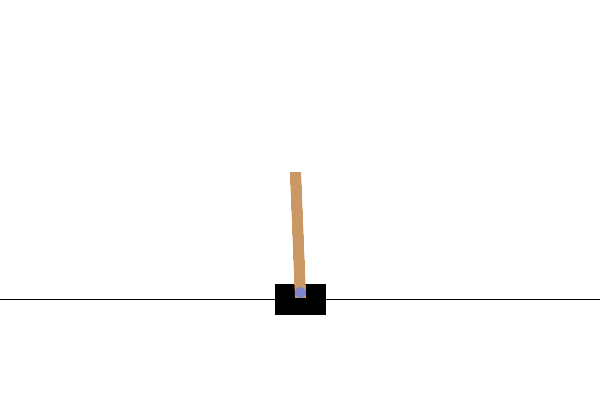

In [16]:
create_gif(env2, mc_agent2, max_steps=1000, seed=1, folder='gifs', filename='cartpole_01')

## 2.E - Q-Learning

Create an instance of `TDAgent` for the environment from 2.A with `gamma=1.0`. Then apply Q-learning using the parameter described below.

* Train for 20,000 episodes.
* Set `max_steps=1000`.
* Set `seed=1`.
* Do NOT Use exploring starts.
* Set `check_success=False`.
* Set `updates=1000`.
* Set `eval_eps=100`.
* Set the learning rate to `0.3`.
* Decay the learning rate at a rate of `5e-6`.
* Set the exploration rate to `1.0`.
* Decay the exploration rate at a rate of `5e-4`.




In [17]:
td_agent2 = TDAgent(env2, gamma=1.0)

td_agent2.q_learning(
    episodes = 20_000,
    max_steps = 1000,
    alpha = 0.3,
    alpha_decay = 5e-6,
    epsilon = 1.0,
    epsilon_decay = 5e-4,
    exploring_starts = False,
    updates = 1000,
    eval_eps = 100,
    check_success = False,
    show_progress = False,
    seed = 1,
)

Episode   Mean[Return]  SD[Return]  Mean[Length]  SD[Length]
------------------------------------------------------------
1000          307.9900    252.5235      308.9300    252.3591  (Saving new best model)
2000          119.7300     29.6438      120.7300     29.6438  (Saving new best model)
3000          170.1900     52.1906      171.1900     52.1906  (Saving new best model)
4000          295.2400    183.2607      296.2300    183.2223  
5000          653.0500    316.1037      653.7100    315.7307  (Saving new best model)
6000          299.2900     79.9014      300.2900     79.9014  
7000          475.5700    272.6092      476.4200    272.3207  
8000         1000.0000      0.0000     1000.0000      0.0000  (Saving new best model)
9000          263.0200    166.2418      264.0000    166.1531  
10000         393.2200    229.1063      394.1800    229.0004  
11000         980.2700    112.2733      980.3000    112.1029  
12000        1000.0000      0.0000     1000.0000      0.0000  
13000  

## 2.F - Evaluating Q-Learning Policy

Use `evaluate()` to evaluate the policy found by the Monte Carlo agent. Set `episodes=500`, `gamma=1.0`, `seed=1`, `max_steps=1000`, and `check_success=False`.


In [18]:
td_results2 = evaluate(env2, td_agent2, gamma=1.0, episodes=500, max_steps=1000, check_success=False, seed=1)

Mean Return:    1000.0
StdDev Return:  0.0
Mean Length:    1000.0
StdDev Length:  0.0


In the cell below, replace the blanks with the name of the dictionary returned by `evaluate()` in the previous step and then run the cell.


In [19]:
print(td_results2['mean_return'] - td_results2['stdev_return'])

1000.0


<hr>

### ⭐ **Extra Credit Opportunity** ⭐

When using the parameters described in 2.E, your agent should have obtained a score of approximately `955.38` in 2.F. f you can obtain a higher score, you might be able to earn some extra credit on this lab. The details are provided below.

* If pursuing extra credit, please adjust only the parameters `episodes`, `alpha`, `alpha_decay`, `epsilon`, and `epsilon_decay`.
* Leave all other parameters as described in 2.E.
* For the sake of time, please do not train for more than 100,000 episodes.
* You will earn 1 point of bonus if your agent obtains a score of 970 or higher.
* You will earn 2 points of bonus if your agent obtains a score of 1000.

**For your final submission, train one and only one model for this task**. If pursuing the extra credit, please include your updates in  the cell provided in Part 2.E. If you use a loop to search through sets of parameter values, please place that code in a separate notebook.
<hr>

## 2.G - Animate an Episode using TD Policy

Use the `create_gif()` function to animate an episode following the policy found by the TD Agent. Store the gif in a folder named `gifs` and name the gif `cartpole_02`. Leave `max_steps` at the default value of 1000. Set a seed for the episode. Adjust the seed until you find an episode with a length of at least 950 steps.

1000 steps completed.
Cumulative reward: 1000.0


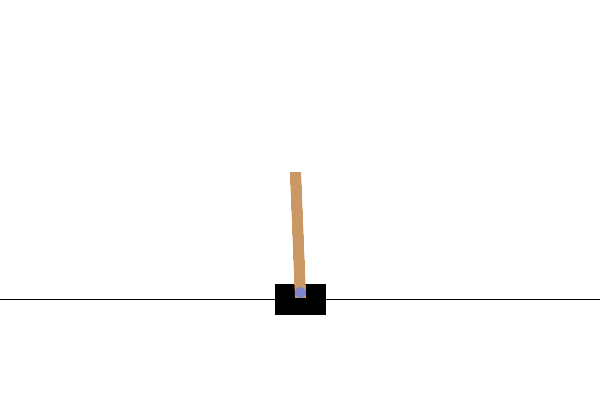

In [20]:
create_gif(env2, td_agent2, max_steps=1000, seed=1, folder='gifs', filename='cartpole_02')

# Submission Instructions

1. Perform a Restart and Run All by clicking **Runtime > Restart session and run all**.
2. Copy the link to your notebook by clicking **Share > Copy Link**.
3. Paste the copied link into the `notebook_url` field in the [Notebook Renderer](https://colab.research.google.com/drive/1CJTipys46ldZxJFwnt7XbdjQUfkmoXeU?usp=sharing) tool and then execute the cell to render the notebook.
4. The Notebook Renderer will open up a save file dialog. Save the resulting HTML file yo your local machine.
5. Submit the HTML file to Canvas.
